In [1]:
import os
import time
import glob
import sys
import argparse
import json
from pathlib import Path
sys.path.append("../..")
#import opensimplex

#from torchvision.utils import save_image

import matplotlib.pyplot as plt
import numpy as np
import csv
import torch
import torch.nn.functional as F
from monai import transforms
from monai.data import CacheDataset, DataLoader, Dataset
from monai.utils import set_determinism
from monai.data.utils import pad_list_data_collate
from torch.amp import autocast
from tqdm import tqdm
import random

import nibabel as nib

from monai.inferers import DiffusionInferer
from monai.networks.nets import DiffusionModelUNet
from monai.networks.schedulers import DDPMScheduler


from monai.utils import StrEnum
from typing import Union

import pandas as pd

import utils.custom_transforms as custom_transforms
import AnoDDPM.simplex as simplex
import utils.simplex_ddpm as simplex_ddpm
from utils.utils import define_instance

from monai.metrics import compute_iou, DiceMetric

import lpips


In [2]:
DEVICE_TYPE = "cuda:0"
device = torch.device(DEVICE_TYPE)

set_determinism(0)

#ROOT_DIR = "/home/fehrdelt/bettik/"
ROOT_DIR = "/bettik/PROJECTS/pr-gin5_aini/fehrdelt/"

In [3]:

torch.backends.cudnn.benchmark = True
torch.set_num_threads(torch.get_num_threads())
torch.autograd.set_detect_anomaly(False)


In [4]:
"""
# ----------- DATA -----------

test_anomaly_images = sorted(glob.glob(ROOT_DIR+"datasets/final_flair_dataset_small/brats_registered/*.nii.gz"))[:64] #otherwise there are too many images (1200)
test_masks = sorted(glob.glob(ROOT_DIR+"datasets/final_flair_dataset_small/brats_masks_registered/*.nii.gz"))[:64] # TODO

# Read the CSV file and put every line in a list
masks_to_exclude = []

with open(ROOT_DIR+"AnoDiffExperiments/data_splits_lists/final_flair_dataset_small/exclude_brats_middle_slice.csv", 'r') as f:
    for line in f:
        masks_to_exclude.append(line.strip())
images_to_exclude = [name.replace("seg", "t2f") for name in masks_to_exclude]

test_anomaly_images = [path for path in test_anomaly_images if os.path.basename(path) not in images_to_exclude]
test_masks = [path for path in test_masks if os.path.basename(path) not in masks_to_exclude]
#print(test_anomaly_images)

num_workers = 4
ano_batch_size = 32

test_anomaly_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128, 128)),
        custom_transforms.ScaleIntensityFromHistogramPeak(target_value=200.0),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=700.0, b_min=0.0, b_max=1.0, clip=True),
        custom_transforms.SetBackgroundToZero(),
        #transforms.EnsureType(device=device, track_meta=False)
    ]
)
test_anomaly_ds = CacheDataset(data=test_anomaly_images, transform=test_anomaly_transforms)

test_anomaly_loader_select_params = DataLoader( # the first 50% of the test data is used to select the best noise timestep value and best threshold.
    test_anomaly_ds[:len(test_anomaly_ds)//2], batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)
test_anomaly_loader_metrics = DataLoader(       # The second 50% is used to compute the final IOU and DICE metrics with these best values.
    test_anomaly_ds[len(test_anomaly_ds)//2:], batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)


test_masks_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128, 128)),
        custom_transforms.SetBackgroundToZero()
    ]
)

test_masks_ds = CacheDataset(data=test_masks, transform=test_masks_transforms)

test_masks_loader_select_params = DataLoader( # the first 50% of the test data is used to select the best noise timestep value and best threshold.
    test_masks_ds[:len(test_masks_ds)//2], batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)
test_masks_loader_metrics = DataLoader(       # The second 50% is used to compute the final IOU and DICE metrics with these best values.
    test_masks_ds[len(test_masks_ds)//2:], batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)
"""

'\n# ----------- DATA -----------\n\ntest_anomaly_images = sorted(glob.glob(ROOT_DIR+"datasets/final_flair_dataset_small/brats_registered/*.nii.gz"))[:64] #otherwise there are too many images (1200)\ntest_masks = sorted(glob.glob(ROOT_DIR+"datasets/final_flair_dataset_small/brats_masks_registered/*.nii.gz"))[:64] # TODO\n\n# Read the CSV file and put every line in a list\nmasks_to_exclude = []\n\nwith open(ROOT_DIR+"AnoDiffExperiments/data_splits_lists/final_flair_dataset_small/exclude_brats_middle_slice.csv", \'r\') as f:\n    for line in f:\n        masks_to_exclude.append(line.strip())\nimages_to_exclude = [name.replace("seg", "t2f") for name in masks_to_exclude]\n\ntest_anomaly_images = [path for path in test_anomaly_images if os.path.basename(path) not in images_to_exclude]\ntest_masks = [path for path in test_masks if os.path.basename(path) not in masks_to_exclude]\n#print(test_anomaly_images)\n\nnum_workers = 4\nano_batch_size = 32\n\ntest_anomaly_transforms = transforms.Compose

In [4]:
test_anomaly_transforms = transforms.Compose(
    [
        transforms.LoadImage(image_only=True),
        transforms.EnsureChannelFirst(),
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128, 128)),
        custom_transforms.ScaleIntensityFromHistogramPeak(target_value=200.0),
        transforms.ScaleIntensityRange(a_min=0.0, a_max=700.0, b_min=0.0, b_max=1.0, clip=True),
        custom_transforms.SetBackgroundToZero(),
        #transforms.EnsureType(device=device, track_meta=False)
    ]
)


test_masks_transforms = transforms.Compose(
    [
        transforms.LoadImage(),
        transforms.EnsureChannelFirst(),
        transforms.ResizeWithPadOrCrop(spatial_size=(128, 128, 128)),
        custom_transforms.SetBackgroundToZero()
    ]
)

In [5]:
large_group = ['sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0023_ses-0001_msk.nii.gz', 'sub-strokecase0031_ses-0001_msk.nii.gz', 'sub-strokecase0047_ses-0001_msk.nii.gz', 'sub-strokecase0048_ses-0001_msk.nii.gz', 'sub-strokecase0062_ses-0001_msk.nii.gz', 'sub-strokecase0066_ses-0001_msk.nii.gz', 'sub-strokecase0081_ses-0001_msk.nii.gz', 'sub-strokecase0083_ses-0001_msk.nii.gz', 'sub-strokecase0087_ses-0001_msk.nii.gz', 'sub-strokecase0091_ses-0001_msk.nii.gz', 'sub-strokecase0123_ses-0001_msk.nii.gz', 'sub-strokecase0161_ses-0001_msk.nii.gz', 'sub-strokecase0162_ses-0001_msk.nii.gz', 'sub-strokecase0171_ses-0001_msk.nii.gz', 'sub-strokecase0176_ses-0001_msk.nii.gz', 'sub-strokecase0201_ses-0001_msk.nii.gz', 'sub-strokecase0211_ses-0001_msk.nii.gz', 'sub-strokecase0222_ses-0001_msk.nii.gz', 'sub-strokecase0223_ses-0001_msk.nii.gz', 'sub-strokecase0230_ses-0001_msk.nii.gz', 'sub-strokecase0237_ses-0001_msk.nii.gz', 'sub-strokecase0240_ses-0001_msk.nii.gz', 'sub-strokecase0246_ses-0001_msk.nii.gz']
large_group_adc_images = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_registered/"+filename.replace("msk", "adc") for filename in large_group]
        
large_group_flair_images = [ROOT_DIR+"datasets/final_flair_dataset_small/isles_registered/"+filename.replace("msk", "FLAIR") for filename in large_group]
large_group_masks = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_masks_registered/"+filename for filename in large_group]

num_workers = 4
ano_batch_size = 32


test_anomaly_large_ds = CacheDataset(data=large_group_adc_images, transform=test_anomaly_transforms)


""" 
test_anomaly_large_loader_select_params = DataLoader(
    test_anomaly_large_ds[:len(test_anomaly_large_ds)//2], batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
) """
test_anomaly_large_loader_metrics = DataLoader(
    test_anomaly_large_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)


test_masks_large_ds = CacheDataset(data=large_group_masks, transform=test_anomaly_transforms)

""" test_masks_large_loader_select_params = DataLoader(
    test_masks_large_ds[:len(test_masks_large_ds)//2], batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
) """
test_masks_large_loader_metrics = DataLoader(
    test_masks_large_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)


Loading dataset: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 42/42 [00:07<00:00,  5.42it/s]


In [29]:
medium_group = ['sub-strokecase0001_ses-0001_msk.nii.gz', 'sub-strokecase0003_ses-0001_msk.nii.gz', 'sub-strokecase0011_ses-0001_msk.nii.gz', 'sub-strokecase0013_ses-0001_msk.nii.gz', 'sub-strokecase0015_ses-0001_msk.nii.gz', 'sub-strokecase0021_ses-0001_msk.nii.gz', 'sub-strokecase0027_ses-0001_msk.nii.gz', 'sub-strokecase0033_ses-0001_msk.nii.gz', 'sub-strokecase0039_ses-0001_msk.nii.gz', 'sub-strokecase0043_ses-0001_msk.nii.gz', 'sub-strokecase0052_ses-0001_msk.nii.gz', 'sub-strokecase0057_ses-0001_msk.nii.gz', 'sub-strokecase0065_ses-0001_msk.nii.gz', 'sub-strokecase0085_ses-0001_msk.nii.gz', 'sub-strokecase0092_ses-0001_msk.nii.gz', 'sub-strokecase0101_ses-0001_msk.nii.gz', 'sub-strokecase0102_ses-0001_msk.nii.gz', 'sub-strokecase0114_ses-0001_msk.nii.gz', 'sub-strokecase0116_ses-0001_msk.nii.gz', 'sub-strokecase0120_ses-0001_msk.nii.gz', 'sub-strokecase0122_ses-0001_msk.nii.gz', 'sub-strokecase0124_ses-0001_msk.nii.gz', 'sub-strokecase0127_ses-0001_msk.nii.gz', 'sub-strokecase0140_ses-0001_msk.nii.gz', 'sub-strokecase0146_ses-0001_msk.nii.gz', 'sub-strokecase0153_ses-0001_msk.nii.gz', 'sub-strokecase0154_ses-0001_msk.nii.gz', 'sub-strokecase0155_ses-0001_msk.nii.gz', 'sub-strokecase0164_ses-0001_msk.nii.gz', 'sub-strokecase0165_ses-0001_msk.nii.gz', 'sub-strokecase0166_ses-0001_msk.nii.gz', 'sub-strokecase0168_ses-0001_msk.nii.gz', 'sub-strokecase0178_ses-0001_msk.nii.gz', 'sub-strokecase0179_ses-0001_msk.nii.gz', 'sub-strokecase0180_ses-0001_msk.nii.gz', 'sub-strokecase0186_ses-0001_msk.nii.gz', 'sub-strokecase0188_ses-0001_msk.nii.gz', 'sub-strokecase0189_ses-0001_msk.nii.gz', 'sub-strokecase0190_ses-0001_msk.nii.gz', 'sub-strokecase0191_ses-0001_msk.nii.gz', 'sub-strokecase0192_ses-0001_msk.nii.gz', 'sub-strokecase0194_ses-0001_msk.nii.gz', 'sub-strokecase0195_ses-0001_msk.nii.gz', 'sub-strokecase0199_ses-0001_msk.nii.gz', 'sub-strokecase0204_ses-0001_msk.nii.gz', 'sub-strokecase0206_ses-0001_msk.nii.gz', 'sub-strokecase0207_ses-0001_msk.nii.gz', 'sub-strokecase0208_ses-0001_msk.nii.gz', 'sub-strokecase0209_ses-0001_msk.nii.gz', 'sub-strokecase0215_ses-0001_msk.nii.gz', 'sub-strokecase0219_ses-0001_msk.nii.gz', 'sub-strokecase0220_ses-0001_msk.nii.gz', 'sub-strokecase0001_ses-0001_msk.nii.gz', 'sub-strokecase0003_ses-0001_msk.nii.gz', 'sub-strokecase0011_ses-0001_msk.nii.gz', 'sub-strokecase0013_ses-0001_msk.nii.gz', 'sub-strokecase0015_ses-0001_msk.nii.gz', 'sub-strokecase0021_ses-0001_msk.nii.gz', 'sub-strokecase0027_ses-0001_msk.nii.gz', 'sub-strokecase0033_ses-0001_msk.nii.gz', 'sub-strokecase0039_ses-0001_msk.nii.gz', 'sub-strokecase0043_ses-0001_msk.nii.gz', 'sub-strokecase0052_ses-0001_msk.nii.gz', 'sub-strokecase0057_ses-0001_msk.nii.gz', 'sub-strokecase0065_ses-0001_msk.nii.gz', 'sub-strokecase0085_ses-0001_msk.nii.gz', 'sub-strokecase0092_ses-0001_msk.nii.gz', 'sub-strokecase0101_ses-0001_msk.nii.gz', 'sub-strokecase0102_ses-0001_msk.nii.gz', 'sub-strokecase0114_ses-0001_msk.nii.gz', 'sub-strokecase0116_ses-0001_msk.nii.gz', 'sub-strokecase0120_ses-0001_msk.nii.gz', 'sub-strokecase0122_ses-0001_msk.nii.gz', 'sub-strokecase0124_ses-0001_msk.nii.gz', 'sub-strokecase0127_ses-0001_msk.nii.gz', 'sub-strokecase0140_ses-0001_msk.nii.gz', 'sub-strokecase0146_ses-0001_msk.nii.gz', 'sub-strokecase0153_ses-0001_msk.nii.gz', 'sub-strokecase0154_ses-0001_msk.nii.gz', 'sub-strokecase0155_ses-0001_msk.nii.gz', 'sub-strokecase0164_ses-0001_msk.nii.gz', 'sub-strokecase0165_ses-0001_msk.nii.gz', 'sub-strokecase0166_ses-0001_msk.nii.gz', 'sub-strokecase0168_ses-0001_msk.nii.gz', 'sub-strokecase0178_ses-0001_msk.nii.gz', 'sub-strokecase0179_ses-0001_msk.nii.gz', 'sub-strokecase0180_ses-0001_msk.nii.gz', 'sub-strokecase0186_ses-0001_msk.nii.gz', 'sub-strokecase0188_ses-0001_msk.nii.gz', 'sub-strokecase0189_ses-0001_msk.nii.gz', 'sub-strokecase0190_ses-0001_msk.nii.gz', 'sub-strokecase0191_ses-0001_msk.nii.gz', 'sub-strokecase0192_ses-0001_msk.nii.gz', 'sub-strokecase0194_ses-0001_msk.nii.gz', 'sub-strokecase0195_ses-0001_msk.nii.gz', 'sub-strokecase0199_ses-0001_msk.nii.gz', 'sub-strokecase0204_ses-0001_msk.nii.gz', 'sub-strokecase0206_ses-0001_msk.nii.gz', 'sub-strokecase0207_ses-0001_msk.nii.gz', 'sub-strokecase0208_ses-0001_msk.nii.gz', 'sub-strokecase0209_ses-0001_msk.nii.gz', 'sub-strokecase0215_ses-0001_msk.nii.gz', 'sub-strokecase0219_ses-0001_msk.nii.gz', 'sub-strokecase0220_ses-0001_msk.nii.gz', 'sub-strokecase0226_ses-0001_msk.nii.gz', 'sub-strokecase0227_ses-0001_msk.nii.gz', 'sub-strokecase0236_ses-0001_msk.nii.gz', 'sub-strokecase0238_ses-0001_msk.nii.gz', 'sub-strokecase0243_ses-0001_msk.nii.gz', 'sub-strokecase0245_ses-0001_msk.nii.gz', 'sub-strokecase0248_ses-0001_msk.nii.gz']
medium_group_adc_images = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_registered/"+filename.replace("msk", "adc") for filename in medium_group]


test_anomaly_medium_ds = CacheDataset(data=medium_group_adc_images, transform=test_anomaly_transforms)

test_anomaly_medium_loader_metrics = DataLoader(
    test_anomaly_medium_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)


Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 111/111 [00:18<00:00,  5.94it/s]


In [36]:
small_group = ['sub-strokecase0004_ses-0001_msk.nii.gz', 'sub-strokecase0009_ses-0001_msk.nii.gz', 'sub-strokecase0010_ses-0001_msk.nii.gz', 'sub-strokecase0017_ses-0001_msk.nii.gz', 'sub-strokecase0022_ses-0001_msk.nii.gz', 'sub-strokecase0024_ses-0001_msk.nii.gz', 'sub-strokecase0026_ses-0001_msk.nii.gz', 'sub-strokecase0036_ses-0001_msk.nii.gz', 'sub-strokecase0038_ses-0001_msk.nii.gz', 'sub-strokecase0040_ses-0001_msk.nii.gz', 'sub-strokecase0041_ses-0001_msk.nii.gz', 'sub-strokecase0049_ses-0001_msk.nii.gz', 'sub-strokecase0053_ses-0001_msk.nii.gz', 'sub-strokecase0054_ses-0001_msk.nii.gz', 'sub-strokecase0056_ses-0001_msk.nii.gz', 'sub-strokecase0064_ses-0001_msk.nii.gz', 'sub-strokecase0067_ses-0001_msk.nii.gz', 'sub-strokecase0074_ses-0001_msk.nii.gz', 'sub-strokecase0076_ses-0001_msk.nii.gz', 'sub-strokecase0080_ses-0001_msk.nii.gz', 'sub-strokecase0082_ses-0001_msk.nii.gz', 'sub-strokecase0084_ses-0001_msk.nii.gz', 'sub-strokecase0090_ses-0001_msk.nii.gz', 'sub-strokecase0095_ses-0001_msk.nii.gz', 'sub-strokecase0097_ses-0001_msk.nii.gz', 'sub-strokecase0108_ses-0001_msk.nii.gz', 'sub-strokecase0110_ses-0001_msk.nii.gz', 'sub-strokecase0129_ses-0001_msk.nii.gz', 'sub-strokecase0137_ses-0001_msk.nii.gz', 'sub-strokecase0145_ses-0001_msk.nii.gz', 'sub-strokecase0152_ses-0001_msk.nii.gz', 'sub-strokecase0158_ses-0001_msk.nii.gz', 'sub-strokecase0159_ses-0001_msk.nii.gz', 'sub-strokecase0163_ses-0001_msk.nii.gz', 'sub-strokecase0167_ses-0001_msk.nii.gz', 'sub-strokecase0169_ses-0001_msk.nii.gz', 'sub-strokecase0182_ses-0001_msk.nii.gz', 'sub-strokecase0183_ses-0001_msk.nii.gz', 'sub-strokecase0185_ses-0001_msk.nii.gz', 'sub-strokecase0187_ses-0001_msk.nii.gz', 'sub-strokecase0193_ses-0001_msk.nii.gz', 'sub-strokecase0196_ses-0001_msk.nii.gz', 'sub-strokecase0197_ses-0001_msk.nii.gz', 'sub-strokecase0200_ses-0001_msk.nii.gz', 'sub-strokecase0210_ses-0001_msk.nii.gz', 'sub-strokecase0214_ses-0001_msk.nii.gz', 'sub-strokecase0218_ses-0001_msk.nii.gz', 'sub-strokecase0004_ses-0001_msk.nii.gz', 'sub-strokecase0009_ses-0001_msk.nii.gz', 'sub-strokecase0010_ses-0001_msk.nii.gz', 'sub-strokecase0017_ses-0001_msk.nii.gz', 'sub-strokecase0022_ses-0001_msk.nii.gz', 'sub-strokecase0024_ses-0001_msk.nii.gz', 'sub-strokecase0026_ses-0001_msk.nii.gz', 'sub-strokecase0036_ses-0001_msk.nii.gz', 'sub-strokecase0038_ses-0001_msk.nii.gz', 'sub-strokecase0040_ses-0001_msk.nii.gz', 'sub-strokecase0041_ses-0001_msk.nii.gz', 'sub-strokecase0049_ses-0001_msk.nii.gz', 'sub-strokecase0053_ses-0001_msk.nii.gz', 'sub-strokecase0054_ses-0001_msk.nii.gz', 'sub-strokecase0056_ses-0001_msk.nii.gz', 'sub-strokecase0064_ses-0001_msk.nii.gz', 'sub-strokecase0067_ses-0001_msk.nii.gz', 'sub-strokecase0074_ses-0001_msk.nii.gz', 'sub-strokecase0076_ses-0001_msk.nii.gz', 'sub-strokecase0080_ses-0001_msk.nii.gz', 'sub-strokecase0082_ses-0001_msk.nii.gz', 'sub-strokecase0084_ses-0001_msk.nii.gz', 'sub-strokecase0090_ses-0001_msk.nii.gz', 'sub-strokecase0095_ses-0001_msk.nii.gz', 'sub-strokecase0097_ses-0001_msk.nii.gz', 'sub-strokecase0108_ses-0001_msk.nii.gz', 'sub-strokecase0110_ses-0001_msk.nii.gz', 'sub-strokecase0129_ses-0001_msk.nii.gz', 'sub-strokecase0137_ses-0001_msk.nii.gz', 'sub-strokecase0145_ses-0001_msk.nii.gz', 'sub-strokecase0152_ses-0001_msk.nii.gz', 'sub-strokecase0158_ses-0001_msk.nii.gz', 'sub-strokecase0159_ses-0001_msk.nii.gz', 'sub-strokecase0163_ses-0001_msk.nii.gz', 'sub-strokecase0167_ses-0001_msk.nii.gz', 'sub-strokecase0169_ses-0001_msk.nii.gz', 'sub-strokecase0182_ses-0001_msk.nii.gz', 'sub-strokecase0183_ses-0001_msk.nii.gz', 'sub-strokecase0185_ses-0001_msk.nii.gz', 'sub-strokecase0187_ses-0001_msk.nii.gz', 'sub-strokecase0193_ses-0001_msk.nii.gz', 'sub-strokecase0196_ses-0001_msk.nii.gz', 'sub-strokecase0197_ses-0001_msk.nii.gz', 'sub-strokecase0200_ses-0001_msk.nii.gz', 'sub-strokecase0210_ses-0001_msk.nii.gz', 'sub-strokecase0214_ses-0001_msk.nii.gz', 'sub-strokecase0218_ses-0001_msk.nii.gz', 'sub-strokecase0225_ses-0001_msk.nii.gz', 'sub-strokecase0229_ses-0001_msk.nii.gz', 'sub-strokecase0232_ses-0001_msk.nii.gz', 'sub-strokecase0235_ses-0001_msk.nii.gz', 'sub-strokecase0244_ses-0001_msk.nii.gz', 'sub-strokecase0247_ses-0001_msk.nii.gz', 'sub-strokecase0249_ses-0001_msk.nii.gz']
small_group_adc_images = [ROOT_DIR+"datasets/final_adc_dataset_small/ISLES_registered/"+filename.replace("msk", "adc") for filename in small_group]

test_anomaly_small_ds = CacheDataset(data=small_group_adc_images, transform=test_anomaly_transforms)

test_anomaly_small_loader_metrics = DataLoader(
    test_anomaly_small_ds, batch_size=ano_batch_size, shuffle=False, num_workers=num_workers, pin_memory=True
)

Loading dataset: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 101/101 [00:15<00:00,  6.36it/s]


In [6]:
model = DiffusionModelUNet(
    spatial_dims=2,
    in_channels=1,
    out_channels=1,
    channels=(32, 64, 64, 64),
    attention_levels=(False, True, True, True),
    num_head_channels=8,
    use_flash_attention=True
)
model.to(device)

model_path = ROOT_DIR+"AnoDiffExperiments/experiment_2/exp_2_2/models/exp_2_2_best_model.pth"
model.load_state_dict(torch.load(model_path, map_location=DEVICE_TYPE))

model.eval()


infer_scheduler = simplex_ddpm.SimplexDDPMScheduler(num_train_timesteps=1000, schedule="cosine", normalize=False)



In [7]:


@torch.no_grad()
def my_sample(image, infer_scheduler, timesteps, return_intermediates=False):
    
    simplexObj = simplex.Simplex_CLASS()

    noise = simplex_ddpm.generate_simplex_noise(simplexObj, image.shape, normalize=False).to(device)

    

    if timesteps >= infer_scheduler.num_train_timesteps:
        print(timesteps, "is too high. Setting to", infer_scheduler.num_train_timesteps-1)

    timesteps_list = torch.Tensor([timesteps for a in range(image.shape[0])]).to(image.device).long()

    image = infer_scheduler.add_noise(image, noise, timesteps_list).to(device) #TODO


    intermediates = []
    intermediates_step = 20

            
    for t in range(timesteps, 0, -1): # va de timesteps à 0
        
        model_output = model(
            image, timesteps=torch.Tensor((t,)).to(device), context=None
        )
        #print(model_output.shape)
        
        image, _ = infer_scheduler.step(model_output, t, image)
    
        if (t== timesteps-1 or t%intermediates_step == 0) and return_intermediates:
            intermediates.append(image)

    if return_intermediates:
        return image, intermediates
    else:
        return image


dm = DiceMetric(reduction="sum")

In [8]:
batch = next(iter(test_anomaly_large_loader_metrics))
batch = batch.to(device)

In [9]:
image = batch[..., batch.shape[-1]//2]
print("Batch shape:", image.shape)

Batch shape: torch.Size([32, 1, 128, 128])


In [10]:


infered = my_sample(image, infer_scheduler, timesteps=100)

In [22]:
def scale_intensity_from_histogram_peak(input_image, target_value=1.0, nbins=100):
    input_np = input_image.cpu().numpy()

    hist, bin_edges = np.histogram(input_np.flatten(), bins=nbins, range=(np.max(input_np)/15.0, np.max(input_np)))

    peak_value = bin_edges[np.argmax(hist)]

    normalized_image = input_image / peak_value * target_value

    return normalized_image

In [12]:
from scipy.signal import find_peaks, peak_prominences

def scale_intensity_from_histogram_peak_improved(input_image, target_value=1.0):    
    
    input_np = input_image.cpu().numpy()

    hist, bin_edges = np.histogram(input_np.flatten(), bins=1000, range=(np.max(input_np)/15.0, np.max(input_np)))

    peak_value = bin_edges[np.argmax(hist)]

    normalized_image = input_image / peak_value * target_value

    return normalized_image

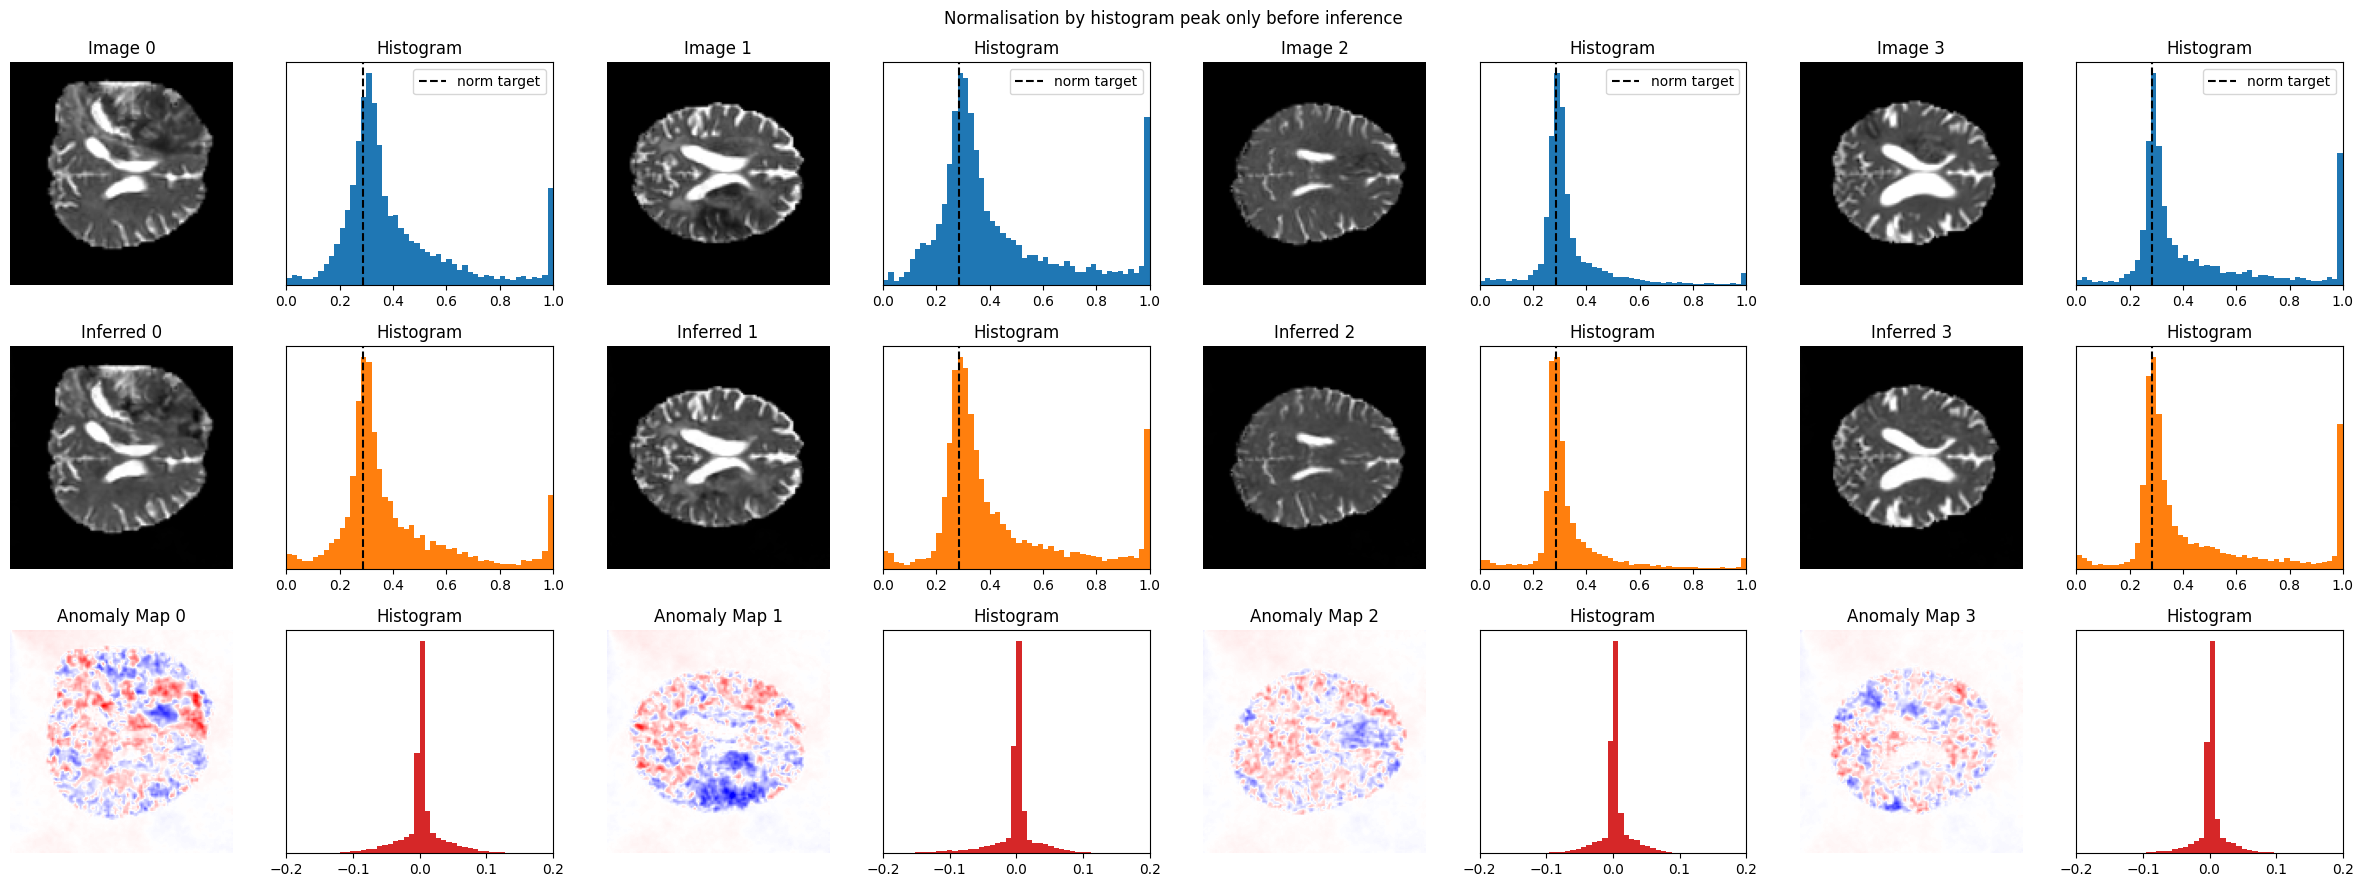

In [17]:
# Display first 4 original slices and corresponding inferred slices, with histograms next to each
n = min(4, image.shape[0])

fig, axes = plt.subplots(3, 2 * n, figsize=(6 * n, 9), tight_layout=True)

for i in range(n):
    # Original
    orig_slice = image[i, 0].detach().cpu().numpy()
    axes[0, 2 * i].imshow(orig_slice, cmap="gray", vmin=0, vmax=1)
    axes[0, 2 * i].set_title(f"Image {i}")
    axes[0, 2 * i].axis("off")

    axes[0, 2 * i + 1].hist(orig_slice[orig_slice > 1e-2].ravel(), bins=50, range=(0, 1), color="tab:blue")
    axes[0, 2 * i + 1].axvline(2/7, color="k", linestyle="--", linewidth=1.5, label="norm target")
    axes[0, 2 * i + 1].set_title("Histogram")
    axes[0, 2 * i + 1].set_xlim(0, 1)
    axes[0, 2 * i + 1].set_yticks([])
    axes[0, 2 * i + 1].legend()

    # Inferred
    inf_slice_t = torch.clamp(infered[i, 0].detach().cpu(), 0, 1)
    inf_slice = inf_slice_t.numpy()
    axes[1, 2 * i].imshow(inf_slice, cmap="gray", vmin=0, vmax=1)
    axes[1, 2 * i].set_title(f"Inferred {i}")
    axes[1, 2 * i].axis("off")

    axes[1, 2 * i + 1].hist(inf_slice[inf_slice > 1e-2].ravel(), bins=50, range=(0, 1), color="tab:orange")
    axes[1, 2 * i + 1].axvline(2/7, color="k", linestyle="--", linewidth=1.5, label="norm target")
    axes[1, 2 * i + 1].set_title("Histogram")
    axes[1, 2 * i + 1].set_xlim(0, 1)
    axes[1, 2 * i + 1].set_yticks([])

    # Anomaly map
    anomaly_map_t = torch.abs(image[i, 0] - infered[i, 0]).detach().cpu()
    anomaly_map = torch.clamp(anomaly_map_t, 0, 1).numpy()
    
    anomaly_map_no_abs = image[i, 0].detach().cpu().numpy() - infered[i, 0].detach().cpu().numpy()
    
    #axes[2, 2 * i].imshow(anomaly_map, cmap="jet", vmin=0, vmax=0.5)
    axes[2, 2 * i].imshow(anomaly_map_no_abs, cmap="bwr", vmin=-0.2, vmax=0.2)
    axes[2, 2 * i].set_title(f"Anomaly Map {i}")
    axes[2, 2 * i].axis("off")

    #axes[2, 2 * i + 1].hist(anomaly_map[anomaly_map > 1e-2].ravel(), bins=50, range=(0, 1), color="tab:red")
    axes[2, 2 * i + 1].hist(anomaly_map_no_abs.ravel(), bins=50, range=(-0.2, 0.2), color="tab:red")
    axes[2, 2 * i + 1].set_title("Histogram")
    axes[2, 2 * i + 1].set_xlim(-0.2, 0.2)
    axes[2, 2 * i + 1].set_yticks([])

plt.suptitle("Normalisation by histogram peak only before inference")
plt.show()

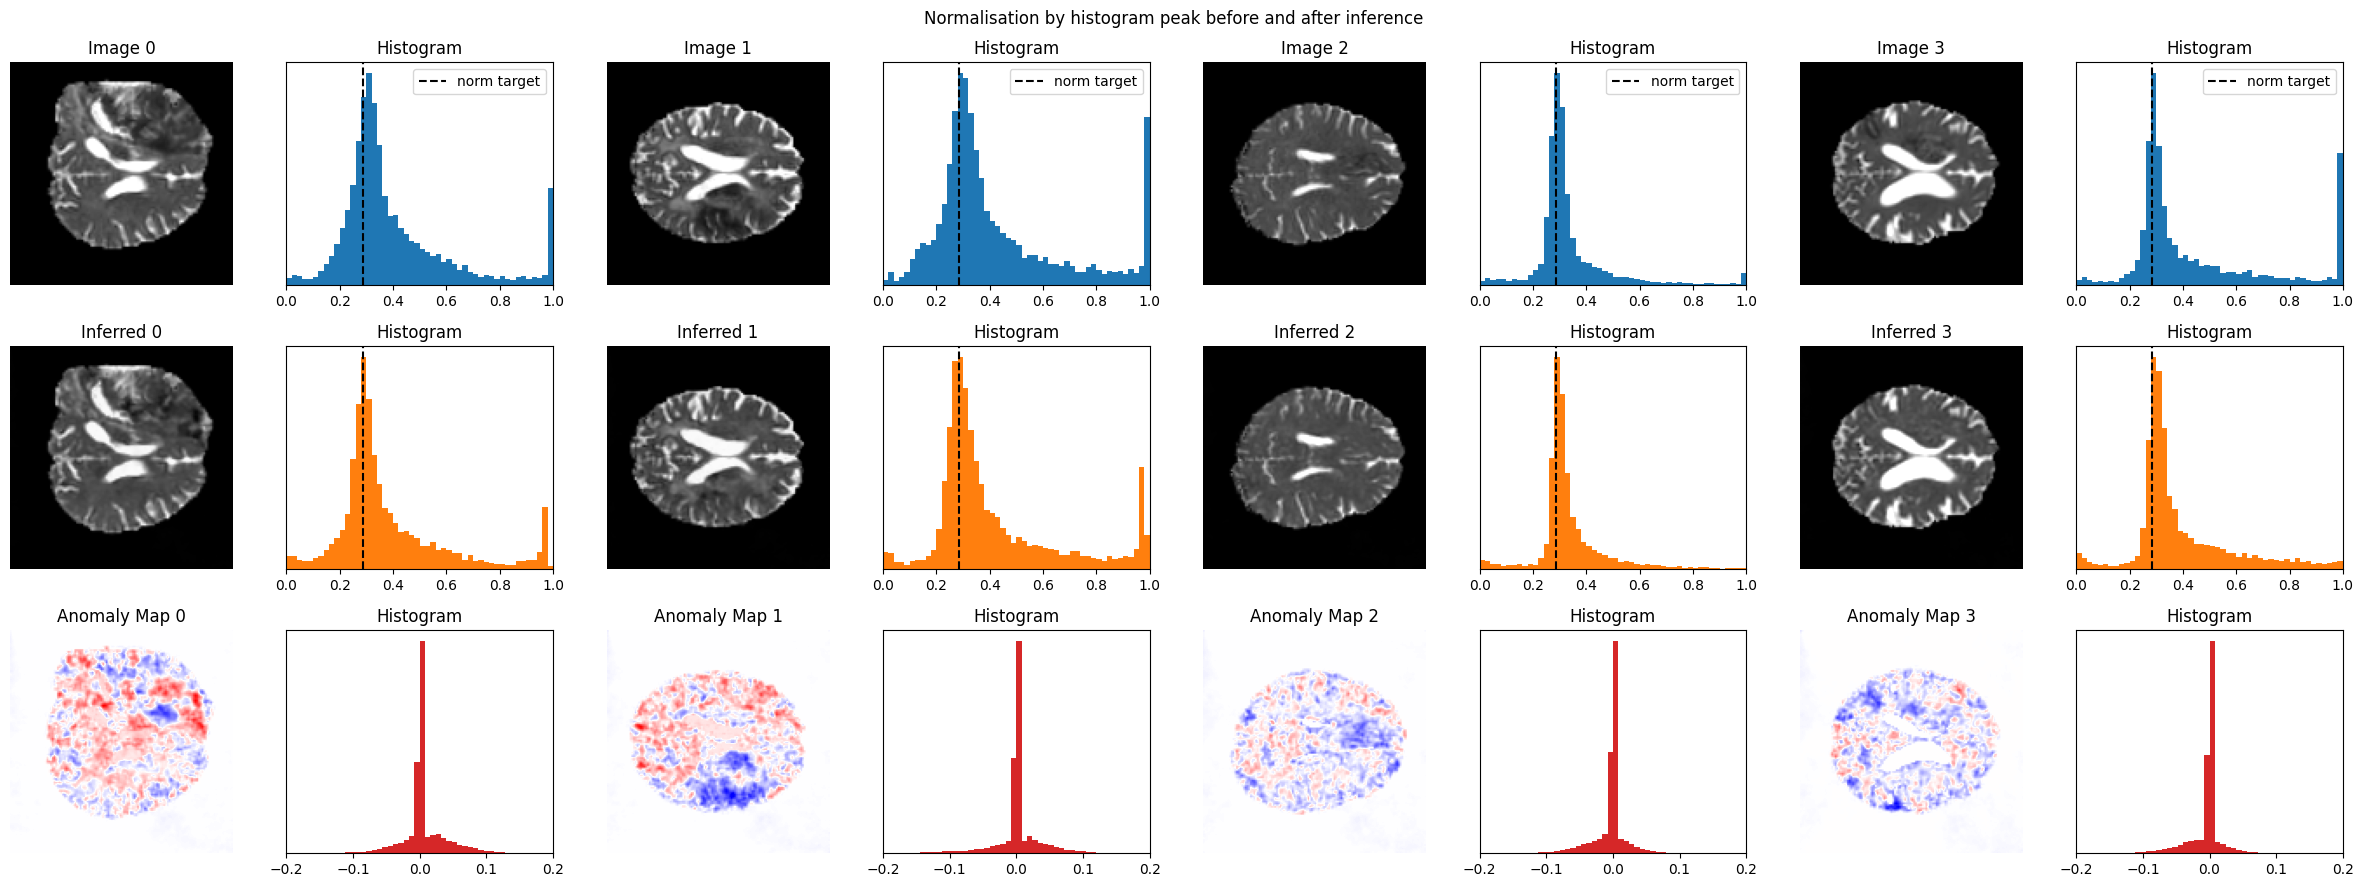

In [25]:
# Display first 4 original slices and corresponding inferred slices, with histograms next to each
n = min(4, image.shape[0])

fig, axes = plt.subplots(3, 2 * n, figsize=(6 * n, 9), tight_layout=True)

for i in range(n):
    # Original
    orig_slice = image[i, 0].detach().cpu().numpy()
    axes[0, 2 * i].imshow(orig_slice, cmap="gray", vmin=0, vmax=1)
    axes[0, 2 * i].set_title(f"Image {i}")
    axes[0, 2 * i].axis("off")

    axes[0, 2 * i + 1].hist(orig_slice[orig_slice > 1e-2].ravel(), bins=50, range=(0, 1), color="tab:blue")
    axes[0, 2 * i + 1].axvline(2/7, color="k", linestyle="--", linewidth=1.5, label="norm target")
    axes[0, 2 * i + 1].set_title("Histogram")
    axes[0, 2 * i + 1].set_xlim(0, 1)
    axes[0, 2 * i + 1].set_yticks([])
    axes[0, 2 * i + 1].legend()

    # Inferred
    inf_slice_t = torch.clamp(infered[i, 0].detach().cpu(), 0, 1)
    inf_slice_t = scale_intensity_from_histogram_peak(infered[i, 0].detach().cpu(), target_value=(2.0/7.0), nbins=100)
    inf_slice = inf_slice_t.numpy()

    axes[1, 2 * i].imshow(inf_slice, cmap="gray", vmin=0, vmax=1)
    axes[1, 2 * i].set_title(f"Inferred {i}")
    axes[1, 2 * i].axis("off")

    axes[1, 2 * i + 1].hist(inf_slice[inf_slice > 1e-2].ravel(), bins=50, range=(0, 1), color="tab:orange")
    axes[1, 2 * i + 1].axvline(2/7, color="k", linestyle="--", linewidth=1.5, label="norm target")
    axes[1, 2 * i + 1].set_title("Histogram")
    axes[1, 2 * i + 1].set_xlim(0, 1)
    axes[1, 2 * i + 1].set_yticks([])

    # Anomaly map
    anomaly_map_t = torch.abs(image[i, 0] - torch.clamp(scale_intensity_from_histogram_peak(infered[i, 0], target_value=(2.0/7.0), nbins=100), 0, 1)).detach().cpu()
    anomaly_map = torch.clamp(anomaly_map_t, 0, 1).numpy()

    anomaly_map_no_abs = (image[i, 0] - torch.clamp(scale_intensity_from_histogram_peak(infered[i, 0], target_value=(2.0/7.0), nbins=100), 0, 1)).detach().cpu().numpy()

    axes[2, 2 * i].imshow(anomaly_map_no_abs, cmap="bwr", vmin=-0.2, vmax=0.2)
    axes[2, 2 * i].set_title(f"Anomaly Map {i}")
    axes[2, 2 * i].axis("off")

    axes[2, 2 * i + 1].hist(anomaly_map_no_abs.ravel(), bins=50, range=(-0.2, 0.2), color="tab:red")
    axes[2, 2 * i + 1].set_title("Histogram")
    axes[2, 2 * i + 1].set_xlim(-0.2, 0.2)
    axes[2, 2 * i + 1].set_yticks([])

plt.suptitle("Normalisation by histogram peak before and after inference")
plt.show()

print how much the peaks were shifted (to the left or to the right)

In [58]:
def display_reconstruction_vs_original(original, inferred, n=1):
    print("display")
    fig, axes = plt.subplots(4, 2, figsize=(6 * 1, 7), tight_layout=True)

    hist_inf, bin_edges_inf = np.histogram(inferred.detach().cpu().numpy().flatten(), bins=1000, range=(np.max(inferred.detach().cpu().numpy())/15.0, np.max(inferred.detach().cpu().numpy())))

    peak_value_inf = bin_edges_inf[np.argmax(hist_inf)]

    # Original
    orig_slice = original.detach().cpu().numpy()
    axes[0, 0].imshow(orig_slice, cmap="gray", vmin=0, vmax=1)
    axes[0, 0].set_title(f"Original {i}")
    axes[0, 0].axis("off")
    # histogram
    axes[0, 1].hist(orig_slice[orig_slice > 1e-2].ravel(), bins=50, range=(0, 1), color="tab:blue")
    axes[0, 1].axvline(2/7, color="k", linestyle="--", linewidth=1.5, label="norm target")
    axes[0, 1].set_title("Histogram")
    axes[0, 1].set_xlim(0, 1)
    axes[0, 1].set_yticks([])
    axes[0, 1].legend()

    # Inferred before histogram peak scaling
    inf_slice = inferred.detach().cpu().numpy()
    axes[1, 0].imshow(inf_slice, cmap="gray", vmin=0, vmax=1)
    axes[1, 0].set_title(f"Inferred before histogram peak scaling {i}")
    axes[1, 0].axis("off")
    # histogram
    axes[1, 1].hist(inf_slice[inf_slice > 1e-2].ravel(), bins=50, range=(0, 1), color="tab:blue")
    axes[1, 1].axvline(2/7, color="k", linestyle="--", linewidth=1.5, label="norm target")
    axes[1, 1].set_title("Histogram")
    axes[1, 1].set_xlim(0, 1)
    axes[1, 1].set_yticks([])
    axes[1, 1].legend()

    # Inferred after histogram peak scaling

    inf_slice_scaled = inf_slice / peak_value_inf * (2.0/7.0)
    axes[2, 0].imshow(inf_slice_scaled, cmap="gray", vmin=0, vmax=1)
    axes[2, 0].set_title(f"Inferred after histogram peak scaling {i}")
    axes[2, 0].axis("off")
    # histogram
    axes[2, 1].hist(inf_slice_scaled[inf_slice_scaled > 1e-2].ravel(), bins=50, range=(0, 1), color="tab:blue")
    axes[2, 1].axvline(2/7, color="k", linestyle="--", linewidth=1.5, label="norm target")
    axes[2, 1].set_title("Histogram")
    axes[2, 1].set_xlim(0, 1)
    axes[2, 1].set_yticks([])
    axes[2, 1].legend()

    # Anomaly map
    anomaly_map = torch.abs(original - inferred / peak_value_inf * (2.0/7.0)).detach().cpu().numpy()
    axes[3, 0].imshow(anomaly_map, cmap="jet", vmin=0, vmax=0.5)
    axes[3, 0].set_title(f"Anomaly Map {i}")
    axes[3, 0].axis("off")
    # histogram
    axes[3, 1].hist(anomaly_map[anomaly_map > 1e-2].ravel(), bins=50, range=(0, 1), color="tab:blue")
    axes[3, 1].set_title("Histogram")
    axes[3, 1].set_xlim(0, 1)
    axes[3, 1].set_yticks([])
    axes[3, 1].legend()

    plt.suptitle("Reconstruction vs Original")
    plt.show()

In [59]:
shifts_list = []

# large anomalies group
for batch in tqdm(test_anomaly_large_loader_metrics):
    batch = batch.to(device)

    image = batch[..., batch.shape[-1]//2]

    infered = my_sample(image, infer_scheduler, timesteps=100)

    for i in range(batch.shape[0]):
        inf_slice = infered[i, 0].detach().cpu().numpy()

        hist_inf, bin_edges_inf = np.histogram(inf_slice.flatten(), bins=1000, range=(np.max(inf_slice)/15.0, 0.8))

        peak_value_inf = bin_edges_inf[np.argmax(hist_inf)]
        shift = peak_value_inf - (2.0/7.0)

        if np.abs(shift)>0.5: # visualize outliers
            display_reconstruction_vs_original(image[i,0], infered[i,0])

        shifts_list.append(shift)
        #print(f"Infered Image {i}: shift compared to target: {shift:.4f}")

# medium anomalies group
for batch in tqdm(test_anomaly_medium_loader_metrics):
    batch = batch.to(device)

    image = batch[..., batch.shape[-1]//2]

    infered = my_sample(image, infer_scheduler, timesteps=100)

    for i in range(batch.shape[0]):
        inf_slice = infered[i, 0].detach().cpu().numpy()

        hist_inf, bin_edges_inf = np.histogram(inf_slice.flatten(), bins=1000, range=(np.max(inf_slice)/15.0, 0.8))

        peak_value_inf = bin_edges_inf[np.argmax(hist_inf)]
        shift = peak_value_inf - (2.0/7.0)

        if np.abs(shift)>0.5: # visualize outliers
            display_reconstruction_vs_original(image[i,0], infered[i,0])


        shifts_list.append(shift)
        #print(f"Infered Image {i}: shift compared to target: {shift:.4f}")


# small anomalies group
for batch in tqdm(test_anomaly_small_loader_metrics):
    batch = batch.to(device)

    image = batch[..., batch.shape[-1]//2]

    infered = my_sample(image, infer_scheduler, timesteps=100)

    for i in range(batch.shape[0]):
        inf_slice = infered[i, 0].detach().cpu().numpy()

        hist_inf, bin_edges_inf = np.histogram(inf_slice.flatten(), bins=1000, range=(np.max(inf_slice)/15.0, 0.8))

        peak_value_inf = bin_edges_inf[np.argmax(hist_inf)]
        shift = peak_value_inf - (2.0/7.0)

        if np.abs(shift)>0.5: # visualize outliers
            display_reconstruction_vs_original(image[i,0], infered[i,0])

        shifts_list.append(shift)
        #print(f"Infered Image {i}: shift compared to target: {shift:.4f}")


print(f"len shifts_list: {len(shifts_list)}")

100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 4/4 [00:51<00:00, 12.77s/it]

len shifts_list: 254


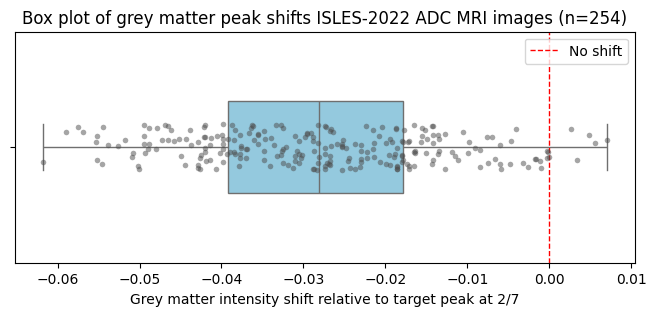

In [60]:
import seaborn as sns

# Ensure list is numeric array
_shifts = np.asarray(shifts_list, dtype=float)

fig, ax = plt.subplots(figsize=(8, 3))
sns.boxplot(x=_shifts, ax=ax, color="skyblue", width=0.4, fliersize=3)
sns.stripplot(x=_shifts, ax=ax, size=4, color=".3", alpha=0.5, jitter=True)
ax.axvline(0.0, color="red", linestyle="--", linewidth=1, label="No shift")
ax.set_title(f"Box plot of grey matter peak shifts ISLES-2022 ADC MRI images (n={len(_shifts)})")
ax.set_xlabel("Grey matter intensity shift relative to target peak at 2/7")
ax.legend(loc="upper right")
plt.show()

### Faire pareil mais avec une vraie detection de pic (scipy) avant et après l'inférence
Et aussi dans la recherche de timesteps, mettre la possibilité d'aller en dessous de 100 timesteps

### Faire pareil mais en réentrainant le modèle ADC avec la vraie détection de pic (scipy)

### Voir carrément normaliser à chaque fois pendant l'entrainement après chaque débruitage